# 04 - Arquitectura del Modelo Cognitivo Artificial (Fases 7-27)

**Modelo Cognitivo Artificial para la Replicación de la Actividad Neurofisiológica de Percepción de Profundidad**

- **Autor:** Jesús Goenaga Peña
- **Programa:** Doctorado en Ciencias Cognitivas - Universidad Autónoma de Manizales

---

Este notebook presenta la arquitectura CNN con ResNet del modelo cognitivo artificial:

| Módulo | Fases | Función Neurofisiológica |
|--------|-------|-------------------------|
| NGL | 7 | Separación magno/parvocelular |
| V1 | 8-15 | Detección de bordes, orientación, movimiento |
| V2 | 16-18 | Bandas gruesas, delgadas, intercaladas |
| V3/V3A | 19-21 | Disparidad binocular, movimiento, formas 3D |
| V4 | 22-24 | Color, formas complejas, atención visual |
| V5/MT | 25-27 | Movimiento, disparidad dinámica, mapas 3D |
| Salida | — | Clasificación binaria (sigmoid) |

## 1. Configuración

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
import torch
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = '/content/drive/MyDrive/cognitive-depth-model'
REPO_DIR = '/content/cognitive-depth-model'

if os.path.exists(REPO_DIR):
    !cd {REPO_DIR} && git pull
else:
    !git clone https://github.com/yisusgoenaga/cognitive-depth-model.git {REPO_DIR}

# Buscar y agregar la ruta de src
import subprocess
result = subprocess.run(['find', REPO_DIR, '-name', 'cognitive_model.py'], capture_output=True, text=True)
model_path = result.stdout.strip()
src_dir = os.path.dirname(os.path.dirname(model_path))
sys.path.insert(0, src_dir)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
print(f'Modelo encontrado en: {model_path}')

Mounted at /content/drive
Cloning into '/content/cognitive-depth-model'...
remote: Enumerating objects: 152, done.
remote: Counting objects: 100% (152/152), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 152 (delta 61), reused 110 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (152/152), 9.20 MiB | 11.46 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Dispositivo: cuda
Modelo encontrado en: /content/cognitive-depth-model/cognitive-depth-model/src/model/cognitive_model.py


## 2. Crear el Modelo

In [2]:
from model.cognitive_model import CognitiveDepthModel, create_model

# Crear el modelo con la configuración por defecto
model = create_model()
model = model.to(device)

print('Modelo Cognitivo Artificial creado exitosamente.')
print(f'Dispositivo: {device}')

Modelo Cognitivo Artificial creado exitosamente.
Dispositivo: cuda


## 3. Análisis de la Arquitectura

In [3]:
# Contar parámetros por módulo
def count_parameters(model):
    """Cuenta parámetros totales y por módulo."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)

print('=' * 65)
print('ARQUITECTURA DEL MODELO COGNITIVO ARTIFICIAL')
print('=' * 65)
print(f'\nParámetros totales:      {total_params:>12,}')
print(f'Parámetros entrenables:  {trainable_params:>12,}')
print(f'Tamaño estimado:         {total_params * 4 / 1e6:>10.1f} MB (float32)')

# Desglose por módulo
print(f'\n{"Módulo":<30} {"Fases":<12} {"Parámetros":>12}')
print('-' * 56)

modules = {
    'NGL': ('7', model.ngl),
    'V1 (Corteza Visual Primaria)': ('8-15', model.v1),
    'V2 (Bandas)': ('16-18', model.v2),
    'V3/V3A (Disparidad + 3D)': ('19-21', model.v3),
    'V4 (Color + Atención)': ('22-24', model.v4),
    'V5/MT (Mapas Dinámicos)': ('25-27', model.v5mt),
    'Integración + Salida': ('—', model.output_layer),
    'Feedback Connections': ('—', None),
}

for name, (phases, module) in modules.items():
    if module is not None:
        params = sum(p.numel() for p in module.parameters())
    else:
        fb_params = sum(p.numel() for p in model.feedback_v2_to_v1.parameters())
        fb_params += sum(p.numel() for p in model.feedback_v3_to_v2.parameters())
        params = fb_params
    print(f'{name:<30} {phases:<12} {params:>12,}')

ARQUITECTURA DEL MODELO COGNITIVO ARTIFICIAL

Parámetros totales:        44,008,641
Parámetros entrenables:    44,008,641
Tamaño estimado:              176.0 MB (float32)

Módulo                         Fases          Parámetros
--------------------------------------------------------
NGL                            7                  43,840
V1 (Corteza Visual Primaria)   8-15              711,488
V2 (Bandas)                    16-18           1,084,800
V3/V3A (Disparidad + 3D)       19-21           6,693,632
V4 (Color + Atención)          22-24           4,068,864
V5/MT (Mapas Dinámicos)        25-27          30,821,888
Integración + Salida           —                 542,593
Feedback Connections           —                  41,536


In [4]:
# Visualización del flujo de información entre módulos
print('\n' + '=' * 65)
print('FLUJO DE INFORMACIÓN DEL MODELO')
print('=' * 65)
print('''
  Entrada: Par estereoscópico (6 canales: 3 RGB × 2 ojos)
     │
     ▼
  ┌─────────────────────────────────────────────┐
  │  FASE 7: NGL                                │
  │  Separación magnocelular / parvocelular     │
  └─────────┬──────────────────┬────────────────┘
            │ (magno)          │ (parvo)
            ▼                  ▼
  ┌─────────────────────────────────────────────┐
  │  FASES 8-15: V1                             │
  │  IV-Cα → IV-Cβ → IV-B → IV-A → II/III      │
  │  → Capa V → Capa VI → Capa I               │
  └───┬──────────┬──────────────┬───────────────┘
      │(IV-B)    │(IV-Cβ)       │(v1_output)
      ▼          ▼              │
  ┌─────────────────────────────────────────────┐
  │  FASES 16-18: V2                            │
  │  Bandas Gruesas → Delgadas → Intercaladas   │
  └───┬──────────┬──────────────┬───────────────┘
      │(gruesas) │(delgadas)    │(intercaladas)
      │          │              │
      ▼          │              ▼
  ┌──────────────┼─────────────────────────┐
  │  FASES 19-21:│V3/V3A                   │
  │  Disparidad →│Movimiento → Formas 3D   │
  └──────────────┼──────────┬──────────────┘
      │          │          │(formas 3D)
      │          ▼          ▼
      │   ┌────────────────────────────────┐
      │   │  FASES 22-24: V4               │
      │   │  Color → Formas → Atención     │
      │   └────────────┬───────────────────┘
      │                │
      ▼                │
  ┌────────────────────┼───────────────────┐
  │  FASES 25-27: V5/MT│                   │
  │  Movimiento → Disparidad → Mapas 3D   │
  └────────────────────┼───────────────────┘
                       │
                       ▼
  ┌─────────────────────────────────────────────┐
  │  INTEGRACIÓN + SALIDA                       │
  │  Concatenación → Dense → Sigmoid            │
  │  → P(Más cercano) ∈ [0, 1]                  │
  └─────────────────────────────────────────────┘
''')


FLUJO DE INFORMACIÓN DEL MODELO

  Entrada: Par estereoscópico (6 canales: 3 RGB × 2 ojos)
     │
     ▼
  ┌─────────────────────────────────────────────┐
  │  FASE 7: NGL                                │
  │  Separación magnocelular / parvocelular     │
  └─────────┬──────────────────┬────────────────┘
            │ (magno)          │ (parvo)
            ▼                  ▼
  ┌─────────────────────────────────────────────┐
  │  FASES 8-15: V1                             │
  │  IV-Cα → IV-Cβ → IV-B → IV-A → II/III      │
  │  → Capa V → Capa VI → Capa I               │
  └───┬──────────┬──────────────┬───────────────┘
      │(IV-B)    │(IV-Cβ)       │(v1_output)
      ▼          ▼              │
  ┌─────────────────────────────────────────────┐
  │  FASES 16-18: V2                            │
  │  Bandas Gruesas → Delgadas → Intercaladas   │
  └───┬──────────┬──────────────┬───────────────┘
      │(gruesas) │(delgadas)    │(intercaladas)
      │          │              │
      ▼    

## 4. Test de Forward Pass

In [5]:
# Test: verificar que el modelo puede procesar un tensor de entrada
# Simulamos un batch de 2 pares estereoscópicos

batch_size = 2
height, width = 256, 512  # Resolución de trabajo definida en model_config.yaml

# Crear entrada sintética: 6 canales (3 RGB × 2 ojos)
dummy_input = torch.randn(batch_size, 6, height, width).to(device)

print(f'Entrada de prueba: {dummy_input.shape}')
print(f'  Batch size: {batch_size}')
print(f'  Canales: 6 (3 RGB × 2 ojos)')
print(f'  Resolución: {height}×{width}')

# Forward pass
model.eval()
with torch.no_grad():
    output = model(dummy_input)

print(f'\nSalida del modelo: {output.shape}')
print(f'  Predicciones: {output.squeeze().cpu().numpy()}')
print(f'  Rango: [{output.min().item():.4f}, {output.max().item():.4f}]')
print(f'\nForward pass exitoso.')

Entrada de prueba: torch.Size([2, 6, 256, 512])
  Batch size: 2
  Canales: 6 (3 RGB × 2 ojos)
  Resolución: 256×512

Salida del modelo: torch.Size([2, 1])
  Predicciones: [2.8463096e-17 1.9574101e-17]
  Rango: [0.0000, 0.0000]

Forward pass exitoso.


## 5. Inspección de Salidas Intermedias

In [6]:
# Obtener las salidas intermedias de cada fase
model.eval()
with torch.no_grad():
    phase_outputs = model.get_phase_outputs(dummy_input)

print('Salidas intermedias del modelo:')
print('=' * 65)
print(f'{"Fase":<35} {"Forma del Tensor":<20} {"Min":>8} {"Max":>8}')
print('-' * 75)

for name, tensor in phase_outputs.items():
    shape_str = str(list(tensor.shape))
    print(f'{name:<35} {shape_str:<20} {tensor.min().item():>8.3f} {tensor.max().item():>8.3f}')

Salidas intermedias del modelo:
Fase                                Forma del Tensor          Min      Max
---------------------------------------------------------------------------
phase7_ngl_magno                    [2, 32, 256, 512]      -0.033    5.593
phase7_ngl_parvo                    [2, 32, 256, 512]      -0.032    4.463
phase8_v1_iv_c_alpha                [2, 64, 256, 512]      -0.072    9.358
phase9_v1_iv_c_beta                 [2, 64, 256, 512]      -0.025    4.161
phase12_v1_layers_ii_iii            [2, 64, 256, 512]      -0.127   24.247
phase15_v1_output                   [2, 64, 256, 512]      -0.369   47.638
phase16_v2_thick                    [2, 128, 128, 256]     -0.117   14.753
phase17_v2_thin                     [2, 128, 128, 256]     -0.062    7.194
phase18_v2_interstripes             [2, 128, 128, 256]     -0.172   22.662
phase19_v3a_disparity               [2, 256, 64, 128]      -0.262   42.529
phase20_v3a_motion                  [2, 256, 64, 128]      -0.300  

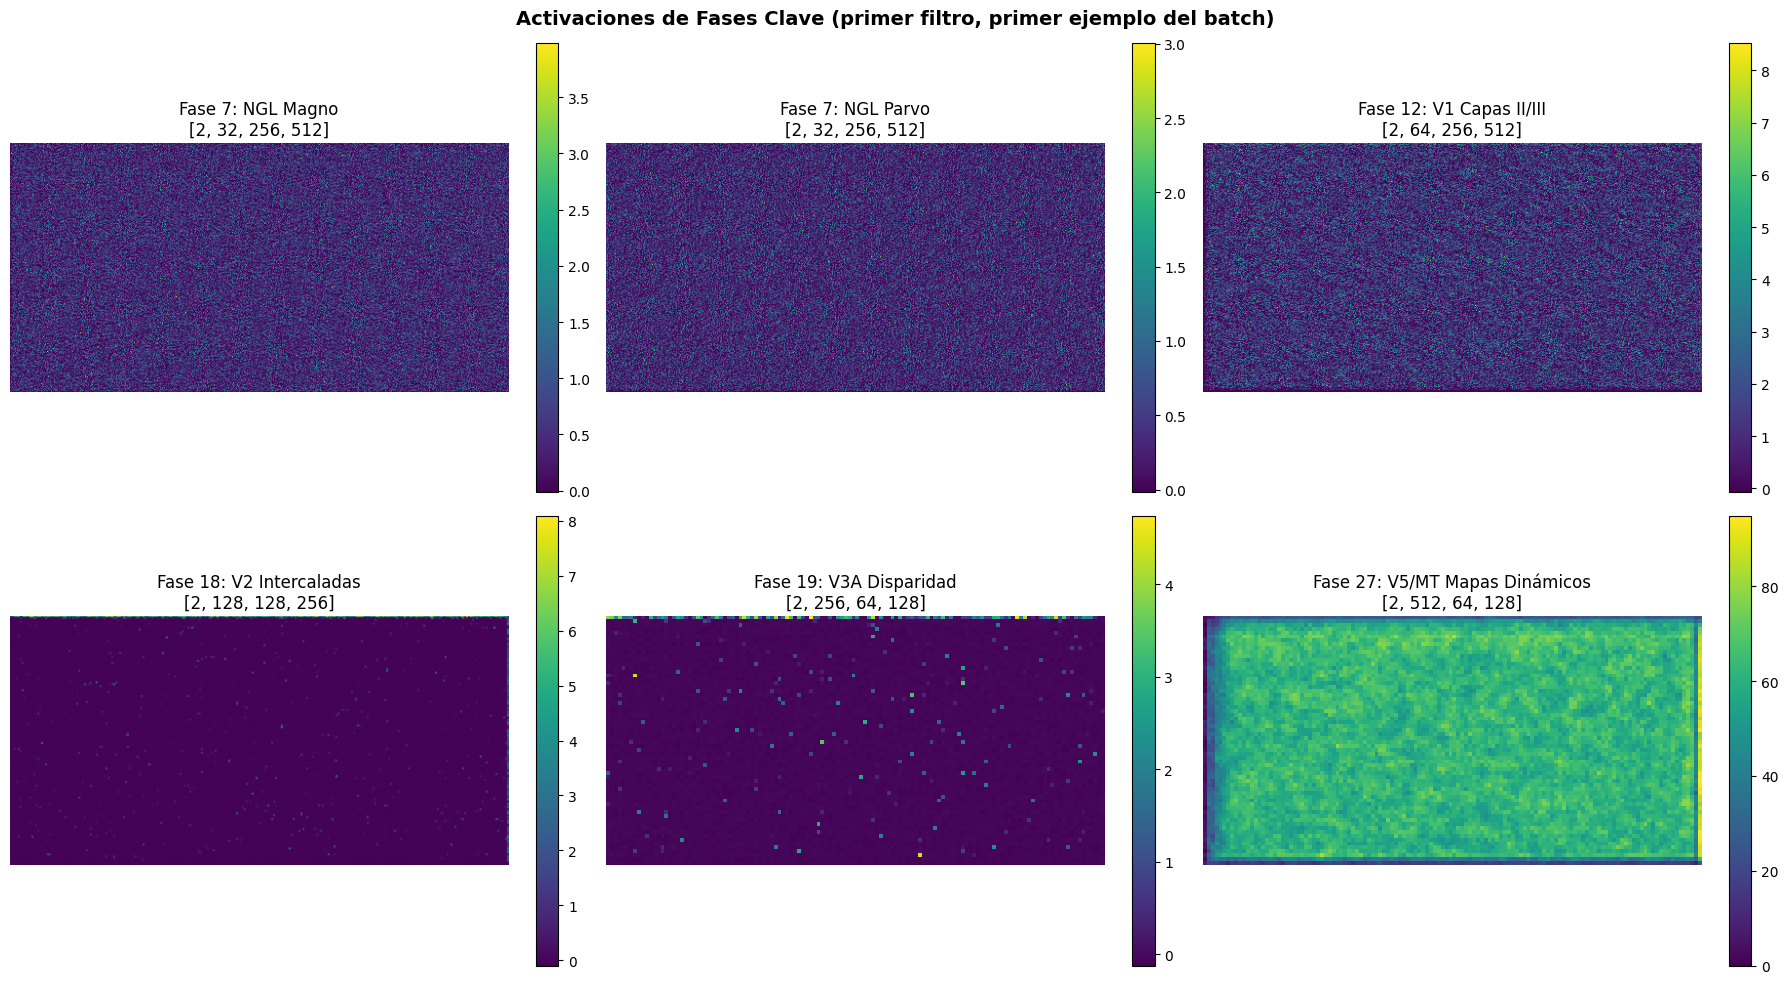

Activaciones guardadas en results/visualizations/phase_activations.png


In [7]:
# Visualizar activaciones de fases clave
key_phases = [
    ('phase7_ngl_magno', 'Fase 7: NGL Magno'),
    ('phase7_ngl_parvo', 'Fase 7: NGL Parvo'),
    ('phase12_v1_layers_ii_iii', 'Fase 12: V1 Capas II/III'),
    ('phase18_v2_interstripes', 'Fase 18: V2 Intercaladas'),
    ('phase19_v3a_disparity', 'Fase 19: V3A Disparidad'),
    ('phase27_v5mt_dynamic_maps', 'Fase 27: V5/MT Mapas Dinámicos'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Activaciones de Fases Clave (primer filtro, primer ejemplo del batch)',
             fontsize=14, fontweight='bold')

for idx, (phase_key, title) in enumerate(key_phases):
    ax = axes[idx // 3, idx % 3]
    tensor = phase_outputs[phase_key]
    # Mostrar el primer filtro del primer ejemplo del batch
    activation = tensor[0, 0].cpu().numpy()
    im = ax.imshow(activation, cmap='viridis')
    ax.set_title(f'{title}\n{list(tensor.shape)}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'results/visualizations/phase_activations.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Activaciones guardadas en results/visualizations/phase_activations.png')

## 6. Guardar Modelo Inicial (sin entrenar)

In [8]:
# Guardar el modelo inicial para referencia
checkpoint_path = os.path.join(PROJECT_ROOT, 'checkpoints/model_initial.pth')
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'in_channels': 6,
        'ngl_magno': 32,
        'ngl_parvo': 32,
        'v1_channels': 64,
        'v2_channels': 128,
        'v3_channels': 256,
        'v4_channels': 256,
        'v5_channels': 512,
        'integration_units': 512,
        'dropout': 0.3,
    },
    'total_params': total_params,
}, checkpoint_path)

size_mb = os.path.getsize(checkpoint_path) / 1e6
print(f'Modelo guardado en: {checkpoint_path}')
print(f'Tamaño: {size_mb:.1f} MB')

Modelo guardado en: /content/drive/MyDrive/cognitive-depth-model/checkpoints/model_initial.pth
Tamaño: 176.4 MB


In [9]:
print('=' * 65)
print('NOTEBOOK 04 COMPLETADO')
print('=' * 65)
print()
print('Arquitectura del modelo:')
print(f'  27 fases funcionales en {len(list(model.children()))} módulos principales')
print(f'  {total_params:,} parámetros entrenables')
print(f'  Entrada: (batch, 6, 256, 512) - Par estereoscópico')
print(f'  Salida:  (batch, 1) - P(más cercano) ∈ [0, 1]')
print(f'  Forward pass verificado con éxito')
print()
print('Siguiente: Notebook 05 - Entrenamiento del Modelo')
print('  Función de pérdida, optimizador Adam, entrenamiento en dos etapas')

NOTEBOOK 04 COMPLETADO

Arquitectura del modelo:
  27 fases funcionales en 9 módulos principales
  44,008,641 parámetros entrenables
  Entrada: (batch, 6, 256, 512) - Par estereoscópico
  Salida:  (batch, 1) - P(más cercano) ∈ [0, 1]
  Forward pass verificado con éxito

Siguiente: Notebook 05 - Entrenamiento del Modelo
  Función de pérdida, optimizador Adam, entrenamiento en dos etapas
